In [1]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

In [2]:
df=pd.read_csv(r'C:\Users\DELL\Downloads\archive (2)\IMDb Movies India.csv',encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [4]:
df.shape

(15509, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [7]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [8]:
#missing value handle
df.dropna(subset=['Rating'],inplace=True)
df.fillna('Unknown',inplace=True)

In [9]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [10]:
df = df.dropna(subset=["Rating"])

In [11]:
#Feature Engineering

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Genre','Director','Actor 1','Actor 2','Actor 3']: 
    df[col] = le.fit_transform(df[col].fillna('unknown').astype(str))

In [13]:
x=df[['Genre','Director','Actor 1','Actor 2','Actor 3']]
y=df['Rating']


In [14]:
#Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42)

In [16]:
print(x_train.shape)

(6335, 5)


In [19]:
print(x_test.shape)

(1584, 5)


In [34]:
print(model)

RandomForestRegressor()


In [ ]:
#Train Model

In [20]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
#Prediction

In [21]:
y_pred = model.predict(x_test)

In [ ]:
#Evaluation

In [22]:
from sklearn.metrics import mean_squared_error,r2_score
print("MSE:",mean_squared_error(y_test,y_pred))
print("R2 score:",r2_score(y_test,y_pred))

MSE: 1.6450270513090977
R2 score: 0.11517018475461127


In [23]:
from sklearn.metrics import mean_absolute_error

print("MAE:",mean_absolute_error(y_test,y_pred))

MAE: 1.0244548926767678


In [24]:
result = pd.DataFrame({'Actual Rating':y_test.values,
                      'Predicted Rating':y_pred})

print(result.head())

   Actual Rating  Predicted Rating
0            3.3             5.577
1            5.3             5.604
2            5.7             5.532
3            7.2             6.251
4            3.5             4.696


In [ ]:
#Graphs
#Actual Rating VS Predicted Rating

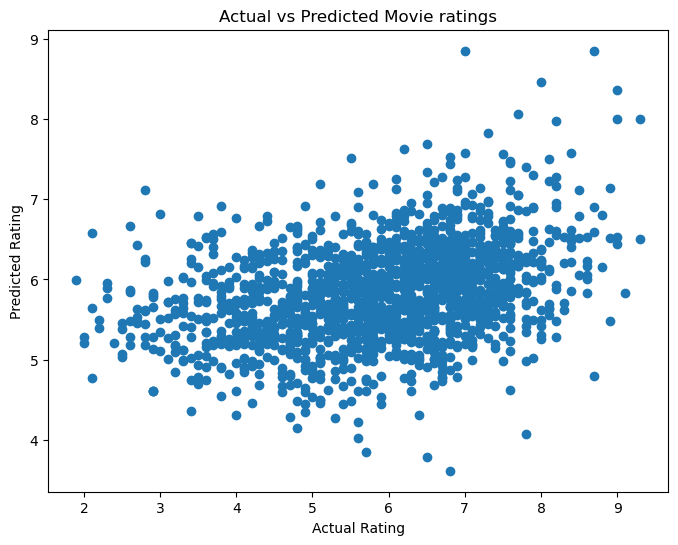

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie ratings")
plt.show()

In [ ]:
#Rating Distribution Histrogram


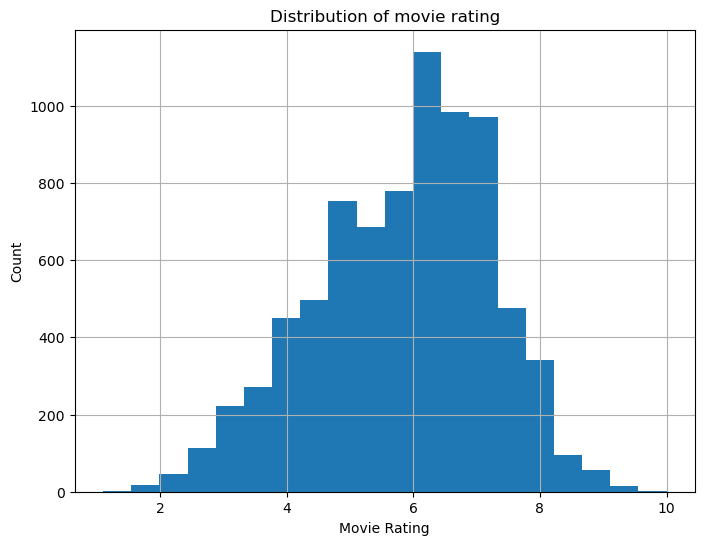

In [29]:
plt.figure(figsize=(8,6))
df['Rating'].hist(bins=20)
plt.xlabel("Movie Rating")
plt.ylabel("Count")
plt.title("Distribution of movie rating")
plt.show()

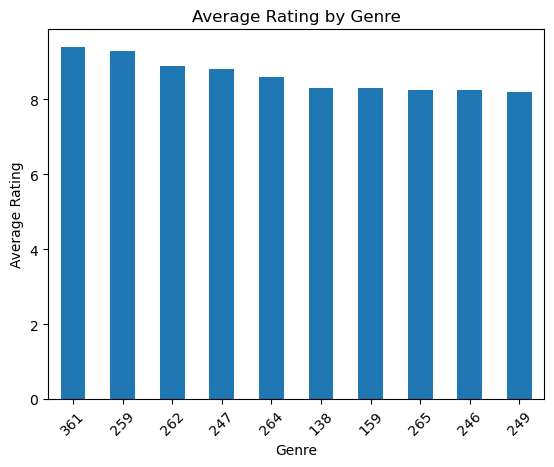

In [33]:
#Genre VS Average Rating
Genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)
Genre_rating.plot(kind ='bar')
plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()